## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, box
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Import our SVF calculation module
import sys
sys.path.insert(0, '/run/media/feds/2309E02F47F328C5/EAGLE/Urban_AZwick/FinalMeasurements')
from svf_calculation import calculate_svf, calculate_svf_batch, calculate_svf_easy, calculate_svf_easy_raycasting

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load OSM Building Data

Load the GeoDataFrame containing OSM building polygons with height information.

In [2]:
# Example: Load your OSM building data
# buildings = gpd.read_file('path_to_your_osm_buildings.gpkg')
# For this example, we'll create sample data

# If you have actual building data, load it like this:
# Check if gpkg files exist in the data directory
import os
data_dir = '/run/media/feds/2309E02F47F328C5/EAGLE/Urban_AZwick/FinalMeasurements/data/osm'

# Try to find buildings data
gpkg_files = [f for f in os.listdir(data_dir) if f.endswith('.gpkg')] if os.path.exists(data_dir) else []
print(f"Available GPKG files in {data_dir}:")
print(gpkg_files if gpkg_files else "No GPKG files found")

Available GPKG files in /run/media/feds/2309E02F47F328C5/EAGLE/Urban_AZwick/FinalMeasurements/data/osm:
['wue_buildings_and_landuse.gpkg']


In [3]:
# Create sample building data for demonstration
# In practice, you would load real OSM data

sample_buildings = {
    'geometry': [
        Polygon([(0, 0), (20, 0), (20, 20), (0, 20)]),
        Polygon([(25, 5), (40, 5), (40, 25), (25, 25)]),
        Polygon([(-15, 10), (0, 10), (0, 30), (-15, 30)]),
        Polygon([(30, -10), (50, -10), (50, 5), (30, 5)]),
    ],
    'height_calc': [25.0, 15.0, 30.0, 12.0],
}


sample_buildings_2 = {
    'geometry': [
        #Polygon([(0, 0), (20, 0), (20, 20), (0, 20)]),
        #Polygon([(25, 5), (40, 5), (40, 25), (25, 25)]),
        #Polygon([(-15, 10), (0, 10), (0, 30), (-15, 30)]),
        Polygon([(30, -10), (50, -10), (50, 5), (30, 5)]),
    ],
    'height_calc': [12.0], #[25.0, 15.0, 30.0, 12.0],
}

buildings_gdf = gpd.GeoDataFrame(
    sample_buildings,
    crs='EPSG:32632'  # UTM zone 32N (example)
)

single_buildings_gdf = gpd.GeoDataFrame(
    sample_buildings_2,
    crs='EPSG:32632'  # UTM zone 32N (example)
)

print("Sample Buildings GeoDataFrame:")
print(buildings_gdf)
print(f"\nCRS: {buildings_gdf.crs}")
print(f"Number of buildings: {len(buildings_gdf)}")

Sample Buildings GeoDataFrame:
                                         geometry  height_calc
0         POLYGON ((0 0, 20 0, 20 20, 0 20, 0 0))         25.0
1      POLYGON ((25 5, 40 5, 40 25, 25 25, 25 5))         15.0
2  POLYGON ((-15 10, 0 10, 0 30, -15 30, -15 10))         30.0
3  POLYGON ((30 -10, 50 -10, 50 5, 30 5, 30 -10))         12.0

CRS: EPSG:32632
Number of buildings: 4


## 3. Understand the SVF Formula

Formula (7) from the paper calculates SVF as:

$$SVF_{PA} = \frac{1}{2\pi \sin(\pi/2n)} \sum_{i=1}^{n} \sin\left[\frac{(2i-1)\pi}{2n}\right] \alpha_i$$

Where:
- **n** = total number of rings (radial divisions of elevation angle)
- **i** = index of each ring (from 1 to n)
- **α_i** = angular width (in radians) of visible sky in the ith ring

The formula divides the hemisphere above the observer into **n** elevation angle rings, and for each ring, calculates what fraction of the 360° azimuth is "open sky" (not blocked by buildings). The weighting function ensures proper integration over the hemisphere.

## 4. SVF Calculation Function

The SVF calculation function:

1. **Identifies nearby buildings** within a maximum distance
2. **For each azimuth direction (0-360°)**: calculates the maximum elevation angle to building silhouettes
3. **For each elevation ring**: determines what fraction of azimuths have visible sky
4. **Applies the weighting function** and normalizes to get SVF ∈ [0, 1]

Key parameters:
- **observer_height**: Height of observer above ground (typically 1.7m for human)
- **num_rings**: Elevation angle divisions (higher = more accurate but slower)
- **max_distance**: Maximum distance to consider buildings (in meters)
- **azimuth_divisions**: Angular directions to check (360 = 1° divisions)

## 5. Calculate SVF for Given Points

### Calculate SVF for Multiple Points

In [4]:
# Define multiple observation points to create a spatial SVF map
test_points = [
    (28, 3),
    (5, 25),
    (-10, 0),
    (20, 30),
    (10, 10),   # Near one building
    (15, 15),   # Center
    (25, 25),   # Near another building
    (5, 5),     # Open area
    (45, 0),    # Far from buildings
]

print("Calculating SVF for multiple points...\n")

svf_results = calculate_svf_batch(
    points=test_points,
    building_gdf=single_buildings_gdf, #buildings_gdf,
    observer_height=1.7,
    num_rings=36,
    max_distance=500.0,
    azimuth_divisions=360,
    verbose=False
)

# Create results dataframe
results_df = pd.DataFrame({
    'Point': test_points,
    'X': [p[0] for p in test_points],
    'Y': [p[1] for p in test_points],
    'SVF': svf_results,
    'Sky_Visibility_%': [f"{s*100:.1f}%" for s in svf_results]
})

print(results_df.to_string(index=False))

Calculating SVF for multiple points...

max elev angles: [1.37900818 1.37897968 1.37889413 1.3787514  1.3785513  1.37829352
 1.37797768 1.37760333 1.37716991 1.37667678 1.37612319 1.37550832
 1.37483124 1.37409091 1.3732862  1.37241586 1.37147854 1.37047274
 1.36939686 1.36824917 1.36702777 1.36573066 1.36435566 1.3629004
 1.36136239 1.35973892 1.35802708 1.35622377 1.35432565 1.35232915
 1.35023043 1.34802537 1.34570956 1.34327828 1.34072644 1.33804859
 1.33523887 1.33229096 1.3291981  1.32595298 1.32254774 1.3189739
 1.31522229 1.31128302 1.30714538 1.30279778 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0. 

### Compare SVF with Different Parameters

In [5]:
# Test how different parameters affect SVF calculation
point = (5, 25)

print("Effect of observer height:")
for height in [0, 1.5, 1.7, 2.0, 5.0]:
    svf = calculate_svf_easy_raycasting(point, buildings_gdf, observer_height=height)
    print(f"  Height {height}m: SVF = {svf:.4f}")

print("\nEffect of number of rings (accuracy):")
for rings in [12, 24, 36, 72]:
    svf = calculate_svf_easy(point, buildings_gdf, num_rings=rings)
    print(f"  {rings} rings: SVF = {svf:.4f}")

print("\nEffect of max distance:")
for dist in [100, 250, 500, 1000]:
    svf = calculate_svf_easy(point, buildings_gdf, max_distance=dist)
    print(f"  {dist}m: SVF = {svf:.4f}")

Effect of observer height:
max elev angles: [0.64350111 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         

## 6. Visualize Results

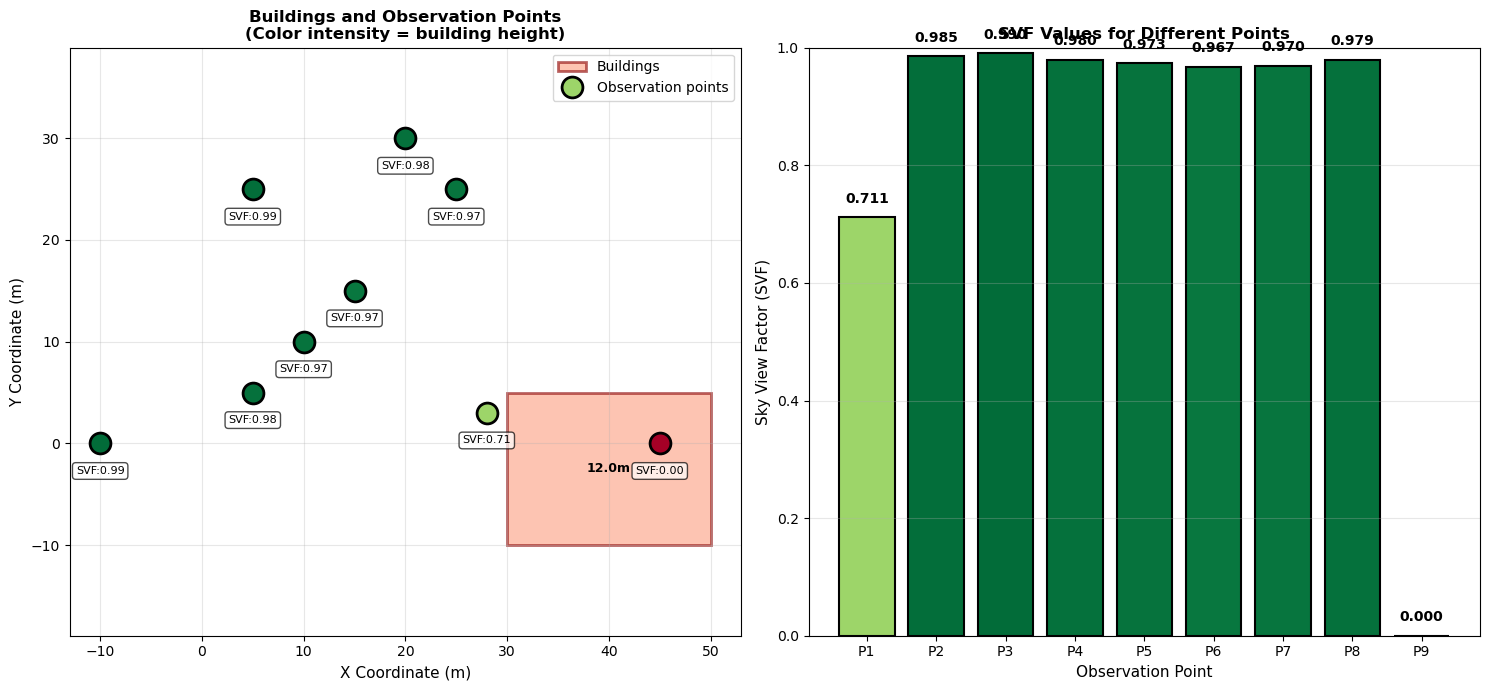

Visualization saved to: SVF_Results.png


In [6]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Plot 1: Buildings and points
ax1 = axes[0]

building_gdf = single_buildings_gdf

# Plot buildings
for idx, (_, building) in enumerate(building_gdf.iterrows()):
    geom = building.geometry
    x, y = geom.exterior.xy
    height = building['height_calc']
    
    # Color based on height
    color_intensity = min(height / 35.0, 1.0)
    ax1.fill(x, y, alpha=0.6, color=plt.cm.Reds(color_intensity), edgecolor='darkred', linewidth=2)
    
    # Add height label
    centroid = geom.centroid
    ax1.text(centroid.x, centroid.y, f"{height}m", ha='center', va='center', fontsize=9, fontweight='bold')

# Plot observation points with SVF values
for point, svf in zip(test_points, svf_results):
    color = plt.cm.RdYlGn(svf)  # Red for low SVF, Green for high SVF
    ax1.plot(point[0], point[1], 'o', markersize=15, color=color, 
             markeredgecolor='black', markeredgewidth=2)
    ax1.text(point[0], point[1]-3, f"SVF:{svf:.2f}", ha='center', fontsize=8, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax1.set_xlabel('X Coordinate (m)', fontsize=11)
ax1.set_ylabel('Y Coordinate (m)', fontsize=11)
ax1.set_title('Buildings and Observation Points\n(Color intensity = building height)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')
ax1.legend(['Buildings', 'Observation points'], loc='upper right')

# Plot 2: SVF values as bar chart
ax2 = axes[1]
colors = [plt.cm.RdYlGn(svf) for svf in svf_results]
bars = ax2.bar(range(len(svf_results)), svf_results, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Sky View Factor (SVF)', fontsize=11)
ax2.set_xlabel('Observation Point', fontsize=11)
ax2.set_title('SVF Values for Different Points', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(svf_results)))
ax2.set_xticklabels([f"P{i+1}" for i in range(len(svf_results))])
ax2.set_ylim([0, 1])
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, (bar, svf) in enumerate(zip(bars, svf_results)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{svf:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/run/media/feds/2309E02F47F328C5/EAGLE/Urban_AZwick/FinalMeasurements/SVF_Results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved to: SVF_Results.png")

## Summary

This notebook demonstrates how to:

1. **Load building data** from OSM or GPKG files with height information
2. **Apply Formula (7)** from the MDPI paper to calculate SVF
3. **Calculate SVF for single and multiple points** in an urban area
4. **Visualize the results** showing how SVF varies with observer location and building surroundings

### Key Insights:
- **Higher SVF values** indicate more open sky (better solar access, higher wind speed)
- **Lower SVF values** indicate more buildings nearby (urban canyon effect, potential urban heat island)
- SVF is useful for urban climate studies, solar potential analysis, and outdoor thermal comfort assessment

### Next Steps:
- Load real OSM building data from your area
- Calculate SVF for your measurement locations
- Compare with other urban morphology metrics
- Analyze relationships with temperature, wind, and pollution measurements